<a href="https://colab.research.google.com/github/Cothilyba77/Projet_final_Force_N/blob/main/Exploration%20de%20donn%C3%A9es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. IMPORTATION DES LIBRAIRIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# importation des données

In [4]:
df_malaria = pd.read_csv('/content/incidence-of-malaria.csv')
df_mortality = pd.read_csv('/content/maternal-mortality.csv')
df_prenatal = pd.read_csv('/content/share-of-mothers-receiving-at-least-one-antenatal-visit-during-pregnancy.csv')

In [5]:
df_malaria.head(5)


,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)"
0,Afghanistan,AFG,2000,84.48
1,Afghanistan,AFG,2001,83.83
2,Afghanistan,AFG,2002,83.79
3,Afghanistan,AFG,2003,70.81
4,Afghanistan,AFG,2004,39.41


In [7]:
df_combined = df_malaria.merge(df_mortality, on=['Entity', 'Year','Code'], how='outer')
df_combined = df_combined.merge(df_prenatal, on=['Entity', 'Year','Code'], how='outer')

In [6]:
df_combined.head(5)

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
0,Afghanistan,AFG,1985,NaN,1910.3416,Asia,NaN,NaN
1,Afghanistan,AFG,1986,NaN,1602.9429,Asia,NaN,NaN
2,Afghanistan,AFG,1987,NaN,1586.7214,Asia,NaN,NaN
3,Afghanistan,AFG,1988,NaN,1413.9326,Asia,NaN,NaN
4,Afghanistan,AFG,1989,NaN,1382.7299,Asia,NaN,NaN


In [7]:
df_present_entities = df_combined.dropna(subset=['Entity'])
display(df_present_entities.head())

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
0,Afghanistan,AFG,1985,NaN,1910.3416,Asia,NaN,NaN
1,Afghanistan,AFG,1986,NaN,1602.9429,Asia,NaN,NaN
2,Afghanistan,AFG,1987,NaN,1586.7214,Asia,NaN,NaN
3,Afghanistan,AFG,1988,NaN,1413.9326,Asia,NaN,NaN
4,Afghanistan,AFG,1989,NaN,1382.7299,Asia,NaN,NaN


In [ ]:
unique_entities = df_combined['Entity'].unique()
display(unique_entities)

array(['Afghanistan', 'Africa', 'Albania', 'Algeria', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Asia', 'Australia',
       'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh',
       'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan',
       'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'British Virgin Islands', 'Brunei', 'Bulgaria', 'Burkina Faso',
       'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo', 'Costa Rica', "Cote d'Ivoire", 'Croatia',
       'Cuba', 'Cyprus', 'Czechia', 'Democratic Republic of Congo',
       'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic',
       'East Asia and Pacific (WB)', 'East Timor', 'Ecuador', 'Egypt',
       'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia',
       'Eswatini', 'Ethiopia', 'Europe', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Ge

In [8]:
west_african_countries = [
    'Benin',
    'Burkina Faso',
    'Cote d\'Ivoire',
    'Gambia',
    'Ghana',
    'Guinea',
    'Guinea-Bissau',
    'Liberia',
    'Mali',
    'Niger',
    'Nigeria',
    'Senegal',
    'Sierra Leone',
    'Togo'
]

df_westafrica = df_combined[df_combined['Entity'].isin(west_african_countries)]
display(df_westafrica.head())

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
984,Benin,BEN,1985,NaN,718.65410,Africa,NaN,NaN
985,Benin,BEN,1986,NaN,681.50360,Africa,NaN,NaN
986,Benin,BEN,1987,NaN,652.18610,Africa,NaN,NaN
987,Benin,BEN,1988,NaN,633.78674,Africa,NaN,NaN
988,Benin,BEN,1989,NaN,591.92160,Africa,NaN,NaN


In [ ]:
df_westafrica.info()

<class 'pandas.core.frame.DataFrame'>
Index: 560 entries, 984 to 8791
Data columns (total 8 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               560 non-null    object 
 1   Code                                                 560 non-null    object 
 2   Year                                                 560 non-null    int64  
 3   Incidence of malaria (per 1,000 population at risk)  350 non-null    float64
 4   Maternal mortality ratio                             504 non-null    float64
 5   World region according to OWID                       504 non-null    object 
 6   Maternal mortality ratio (Annotations)               0 non-null      object 
 7   Pregnant women receiving prenatal care (%)           120 non-null    float64
dtypes: float64(3), int64(1), object(4)
memory usage: 39.4+ KB


In [ ]:
df_westafrica.isna().sum()

,0
Entity,0
Code,0
Year,0
"Incidence of malaria (per 1,000 population at risk)",210
Maternal mortality ratio,56
World region according to OWID,56
Maternal mortality ratio (Annotations),560
Pregnant women receiving prenatal care (%),440


<Axes: >

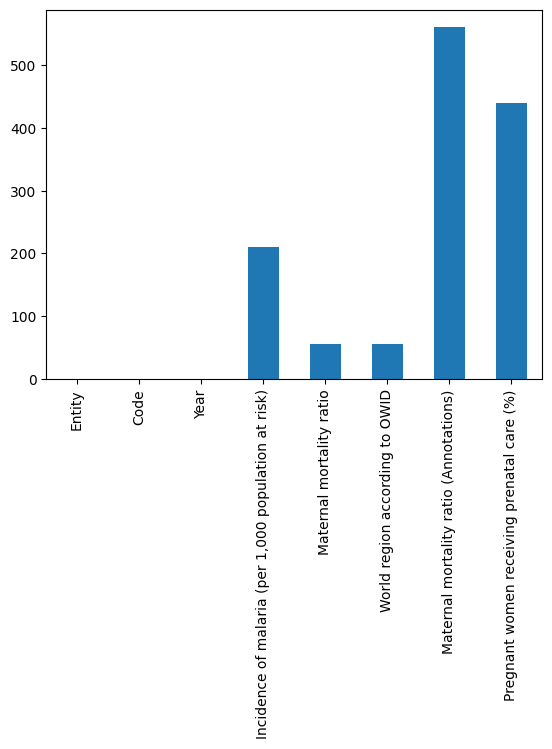

In [ ]:
df_westafrica.isna().sum().plot(kind='bar')

In [ ]:
missing_by_entity = df_westafrica.groupby('Entity').apply(lambda x: x.isnull().sum())
display(missing_by_entity)

/tmp/ipykernel_6358/3118465213.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_entity = df_westafrica.groupby('Entity').apply(lambda x: x.isnull().sum())


,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
Entity,,,,,,,,
Benin,0,0,0,15,4,4,40,34
Burkina Faso,0,0,0,15,4,4,40,32
Cote d'Ivoire,0,0,0,15,4,4,40,33
Gambia,0,0,0,15,4,4,40,34
Ghana,0,0,0,15,4,4,40,25
Guinea,0,0,0,15,4,4,40,31
Guinea-Bissau,0,0,0,15,4,4,40,35
Liberia,0,0,0,15,4,4,40,32
Mali,0,0,0,15,4,4,40,32


In [ ]:
df_westafrica.head(560)

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
984,Benin,BEN,1985,NaN,718.65410,Africa,NaN,NaN
985,Benin,BEN,1986,NaN,681.50360,Africa,NaN,NaN
986,Benin,BEN,1987,NaN,652.18610,Africa,NaN,NaN
987,Benin,BEN,1988,NaN,633.78674,Africa,NaN,NaN
988,Benin,BEN,1989,NaN,591.92160,Africa,NaN,NaN
...,...,...,...,...,...,...,...,...
8787,Togo,TGO,2020,283.92,399.03983,Africa,NaN,NaN
8788,Togo,TGO,2021,279.51,NaN,NaN,NaN,NaN
8789,Togo,TGO,2022,278.59,NaN,NaN,NaN,NaN
8790,Togo,TGO,2023,264.80,NaN,NaN,NaN,NaN


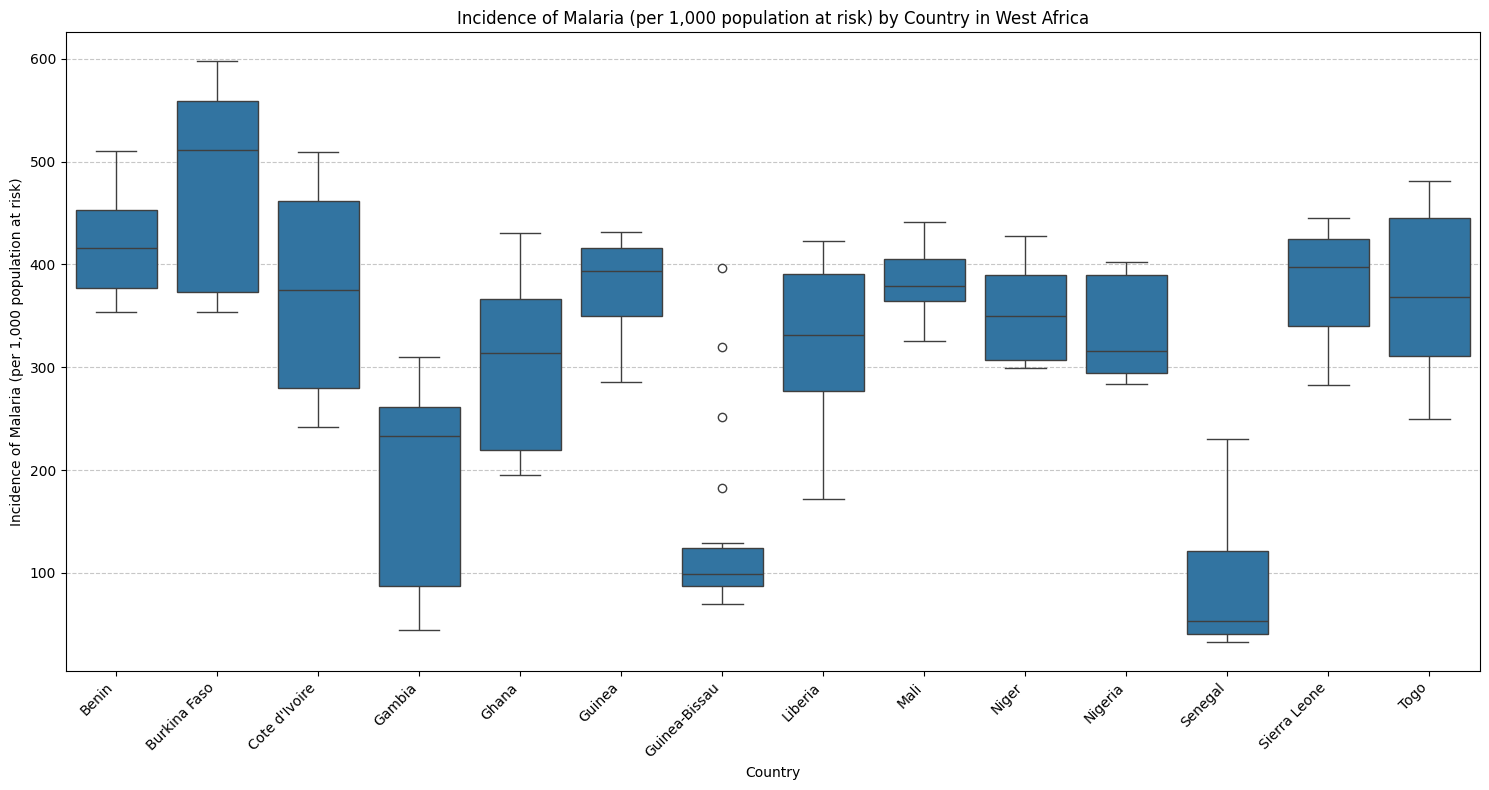

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for Incidence of malaria by country
fig_malaria = plt.figure(figsize=(15, 8))
sns.boxplot(x='Entity', y='Incidence of malaria (per 1,000 population at risk)', data=df_westafrica)
plt.title('Incidence of Malaria (per 1,000 population at risk) by Country in West Africa')
plt.xlabel('Country')
plt.ylabel('Incidence of Malaria (per 1,000 population at risk)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [15]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_malaria) # Uncomment and run if you have 'upload_plt_to_gcs' function defined

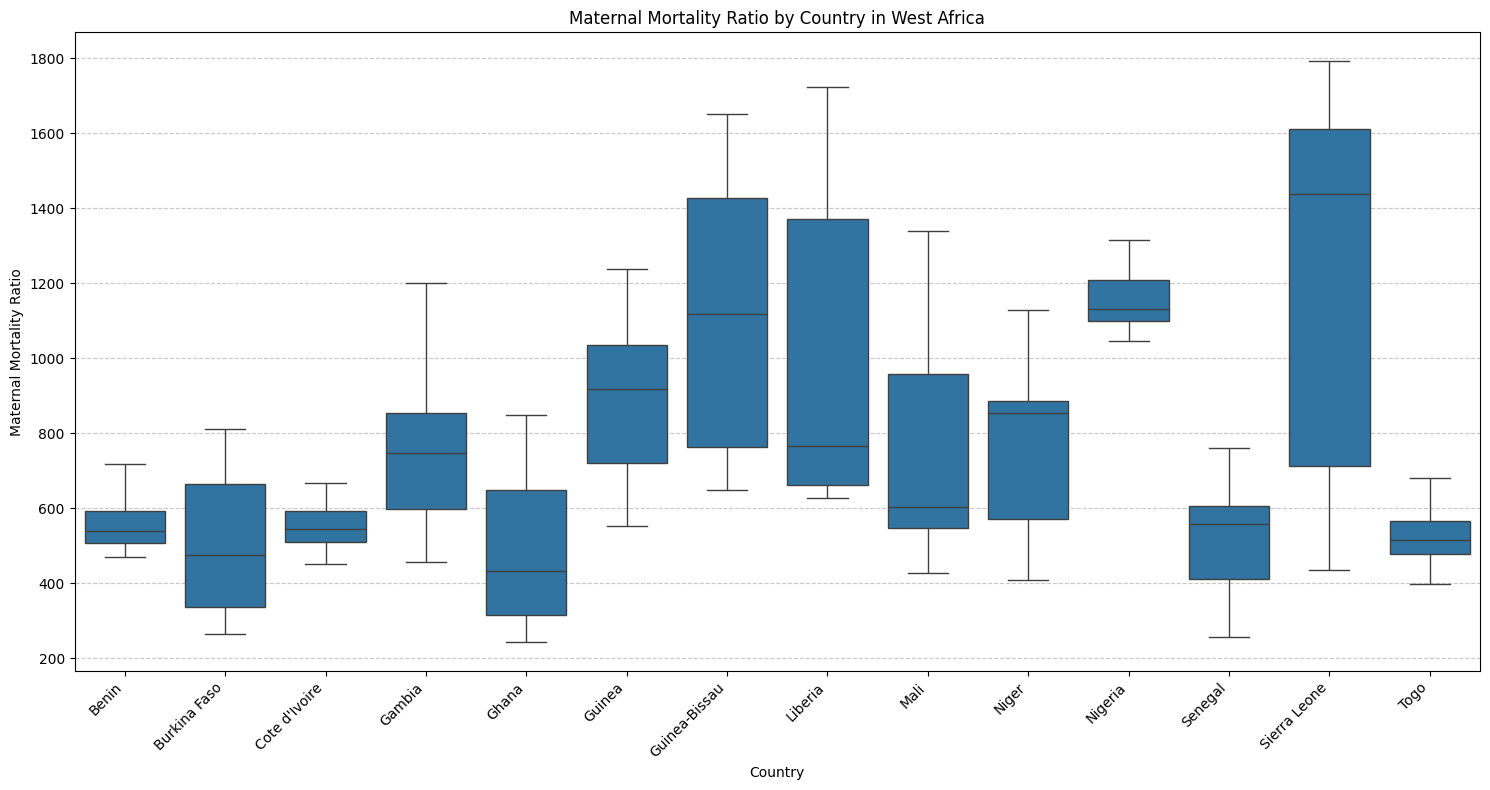

In [16]:
# Boxplot for Maternal mortality ratio by country
fig_mortality = plt.figure(figsize=(15, 8))
sns.boxplot(x='Entity', y='Maternal mortality ratio', data=df_westafrica)
plt.title('Maternal Mortality Ratio by Country in West Africa')
plt.xlabel('Country')
plt.ylabel('Maternal Mortality Ratio')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_mortality) # Uncomment and run if you have 'upload_plt_to_gcs' function defined

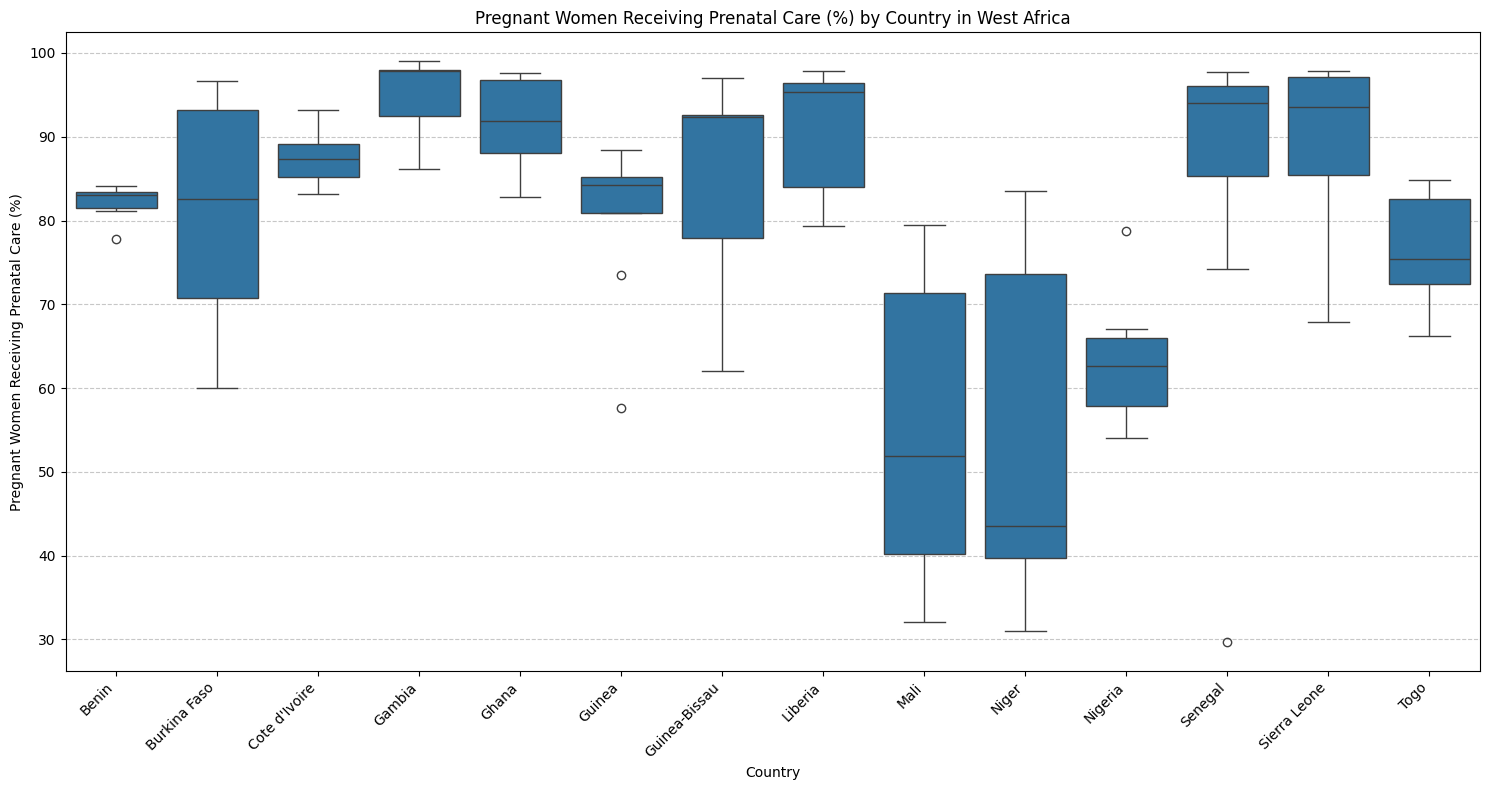

In [18]:
# Boxplot for Pregnant women receiving prenatal care by country
fig_prenatal = plt.figure(figsize=(15, 8))
sns.boxplot(x='Entity', y='Pregnant women receiving prenatal care (%)', data=df_westafrica)
plt.title('Pregnant Women Receiving Prenatal Care (%) by Country in West Africa')
plt.xlabel('Country')
plt.ylabel('Pregnant Women Receiving Prenatal Care (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig_prenatal) # Uncomment and run if you have 'upload_plt_to_gcs' function defined

In [20]:
# Filter df_westafrica to include data from the year 2000 onwards
df_westafrica_2000_onwards = df_westafrica[df_westafrica['Year'] >= 2000]

# Display the head of the new DataFrame
display(df_westafrica_2000_onwards.head())

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,World region according to OWID,Maternal mortality ratio (Annotations),Pregnant women receiving prenatal care (%)
999,Benin,BEN,2000,416.00,469.30765,Africa,NaN,NaN
1000,Benin,BEN,2001,434.27,483.21680,Africa,NaN,81.1
1001,Benin,BEN,2002,453.46,505.33972,Africa,NaN,NaN
1002,Benin,BEN,2003,473.30,504.64990,Africa,NaN,NaN
1003,Benin,BEN,2004,495.55,519.95170,Africa,NaN,NaN


In [21]:
# Create a new DataFrame by dropping the specified columns
df_westafrica_cleaned = df_westafrica_2000_onwards.drop(columns=['World region according to OWID', 'Maternal mortality ratio (Annotations)'])

# Display the head of the new DataFrame
display(df_westafrica_cleaned.head())

,Entity,Code,Year,"Incidence of malaria (per 1,000 population at risk)",Maternal mortality ratio,Pregnant women receiving prenatal care (%)
999,Benin,BEN,2000,416.00,469.30765,NaN
1000,Benin,BEN,2001,434.27,483.21680,81.1
1001,Benin,BEN,2002,453.46,505.33972,NaN
1002,Benin,BEN,2003,473.30,504.64990,NaN
1003,Benin,BEN,2004,495.55,519.95170,NaN


In [10]:
df_westafrica_2000_onwards.info()

<class 'pandas.core.frame.DataFrame'>
Index: 350 entries, 999 to 8791
Data columns (total 8 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Entity                                               350 non-null    object 
 1   Code                                                 350 non-null    object 
 2   Year                                                 350 non-null    int64  
 3   Incidence of malaria (per 1,000 population at risk)  350 non-null    float64
 4   Maternal mortality ratio                             294 non-null    float64
 5   World region according to OWID                       294 non-null    object 
 6   Maternal mortality ratio (Annotations)               0 non-null      object 
 7   Pregnant women receiving prenatal care (%)           95 non-null     float64
dtypes: float64(3), int64(1), object(4)
memory usage: 24.6+ KB


In [38]:
U5mort = pd.read_csv('/content/under_five_years_mortality.csv')
preg_women= pd.read_csv('/content/pregnant_women_prenatalwa.csv')
mat_mort= pd.read_csv('/content/Maternal_mortality_wa.csv')

In [44]:
selected_columns = ['Country', 'Indicator', 'Period', 'Disaggregation', 'Data Source', 'Value']

# Sélectionner les colonnes pour U5mort
U5mort = U5mort[selected_columns]

# Sélectionner les colonnes pour preg_women
preg_women = preg_women[selected_columns]

# Sélectionner les colonnes pour mat_mort
mat_mort = mat_mort[selected_columns]

print('U5mort DataFrame après sélection des colonnes :')
display(U5mort.head())

print('\npreg_women DataFrame après sélection des colonnes :')
display(preg_women.head())

print('\nmat_mort DataFrame après sélection des colonnes :')
display(mat_mort.head())

U5mort DataFrame après sélection des colonnes :


,Country,Indicator,Period,Disaggregation,Data Source,Value
0,BENIN,Neonatal mortality rate (per 1 000 live births...,2000,Both sexes (male and female),WHO/Global Health Observatory,39.86
1,BENIN,Neonatal mortality rate (per 1 000 live births...,2001,Both sexes (male and female),WHO/Global Health Observatory,39.07
2,BENIN,Neonatal mortality rate (per 1 000 live births...,2002,Both sexes (male and female),WHO/Global Health Observatory,38.29
3,BENIN,Neonatal mortality rate (per 1 000 live births...,2003,Both sexes (male and female),WHO/Global Health Observatory,37.57
4,BENIN,Neonatal mortality rate (per 1 000 live births...,2004,Both sexes (male and female),WHO/Global Health Observatory,36.90



preg_women DataFrame après sélection des colonnes :


,Country,Indicator,Period,Disaggregation,Data Source,Value
0,BENIN,Percentage of pregnant women that made at leas...,2001,Rural,WHO/UNICEF,77.1
1,BENIN,Percentage of pregnant women that made at leas...,2001,Urban,WHO/UNICEF,89.5
2,BENIN,Percentage of pregnant women that made at leas...,2001,Total,WHO/UNICEF,81.1
3,BENIN,Percentage of pregnant women that made at leas...,2006,Rural,WHO/UNICEF,80.4
4,BENIN,Percentage of pregnant women that made at leas...,2006,Urban,WHO/UNICEF,91.0



mat_mort DataFrame après sélection des colonnes :


,Country,Indicator,Period,Disaggregation,Data Source,Value
0,BENIN,"Maternal mortality ratio (per 100,000 live bir...",2000,Female,WHO/Global Health Observatory,520.0
1,BENIN,"Maternal mortality ratio (per 100,000 live bir...",2001,Female,WHO/Global Health Observatory,516.0
2,BENIN,"Maternal mortality ratio (per 100,000 live bir...",2002,Female,WHO/Global Health Observatory,511.0
3,BENIN,"Maternal mortality ratio (per 100,000 live bir...",2003,Female,WHO/Global Health Observatory,510.0
4,BENIN,"Maternal mortality ratio (per 100,000 live bir...",2004,Female,WHO/Global Health Observatory,505.0


In [45]:
# Filter U5mort to keep only rows where Disaggregation is 'Both sexes (male and female)'
U5mort_filtered = U5mort[U5mort['Disaggregation'] == 'Both sexes (male and female)']

print('U5mort DataFrame après filtrage par disaggregation :')
display(U5mort_filtered.head())

U5mort DataFrame après filtrage par disaggregation :


,Country,Indicator,Period,Disaggregation,Data Source,Value
0,BENIN,Neonatal mortality rate (per 1 000 live births...,2000,Both sexes (male and female),WHO/Global Health Observatory,39.86
1,BENIN,Neonatal mortality rate (per 1 000 live births...,2001,Both sexes (male and female),WHO/Global Health Observatory,39.07
2,BENIN,Neonatal mortality rate (per 1 000 live births...,2002,Both sexes (male and female),WHO/Global Health Observatory,38.29
3,BENIN,Neonatal mortality rate (per 1 000 live births...,2003,Both sexes (male and female),WHO/Global Health Observatory,37.57
4,BENIN,Neonatal mortality rate (per 1 000 live births...,2004,Both sexes (male and female),WHO/Global Health Observatory,36.90


In [43]:
U5mort_filtered.head(50)

,Country,Indicator,Period,Disaggregation,Data Source,Value
0,BENIN,Neonatal mortality rate (per 1 000 live births...,2000,Both sexes (male and female),WHO/Global Health Observatory,39.86
1,BENIN,Neonatal mortality rate (per 1 000 live births...,2001,Both sexes (male and female),WHO/Global Health Observatory,39.07
2,BENIN,Neonatal mortality rate (per 1 000 live births...,2002,Both sexes (male and female),WHO/Global Health Observatory,38.29
3,BENIN,Neonatal mortality rate (per 1 000 live births...,2003,Both sexes (male and female),WHO/Global Health Observatory,37.57
4,BENIN,Neonatal mortality rate (per 1 000 live births...,2004,Both sexes (male and female),WHO/Global Health Observatory,36.90
5,BENIN,Neonatal mortality rate (per 1 000 live births...,2005,Both sexes (male and female),WHO/Global Health Observatory,36.38
6,BENIN,Neonatal mortality rate (per 1 000 live births...,2006,Both sexes (male and female),WHO/Global Health Observatory,35.95
7,BENIN,Neonatal mortality rate (per 1 000 live births...,2007,Both sexes (male and female),WHO/Global Health Observatory,35.61
8,BENIN,Neonatal mortality rate (per 1 000 live births...,2008,Both sexes (male and female),WHO/Global Health Observatory,35.31
9,BENIN,Neonatal mortality rate (per 1 000 live births...,2009,Both sexes (male and female),WHO/Global Health Observatory,35.01


In [55]:
# Pour chaque pays et chaque année, ne conserver que la première valeur
U5mort_filtered_unique_per_year_country = U5mort_filtered.groupby(['Country', 'Period']).first().reset_index()

print('U5mort DataFrame avec une seule valeur par pays et par année :')
display(U5mort_filtered_unique_per_year_country.head())

U5mort DataFrame avec une seule valeur par pays et par année :


,Country,Period,Indicator,Disaggregation,Data Source,Value
0,BENIN,2000,Neonatal mortality rate (per 1 000 live births...,Both sexes (male and female),WHO/Global Health Observatory,39.86
1,BENIN,2001,Neonatal mortality rate (per 1 000 live births...,Both sexes (male and female),WHO/Global Health Observatory,39.07
2,BENIN,2002,Neonatal mortality rate (per 1 000 live births...,Both sexes (male and female),WHO/Global Health Observatory,38.29
3,BENIN,2003,Neonatal mortality rate (per 1 000 live births...,Both sexes (male and female),WHO/Global Health Observatory,37.57
4,BENIN,2004,Neonatal mortality rate (per 1 000 live births...,Both sexes (male and female),WHO/Global Health Observatory,36.90
